# Geometric Transformations with OpenCV
**Author:** Matheus Leite  
**Date:** May 24, 2025  
This notebook demonstrates how to perform geometric transformations on images using OpenCV. We apply resizing, translation, rotation, flipping, and slicing to manipulate image structure.


## 1. Imports and Image Loading
We import the required libraries and load an image in RGB format to start processing.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("../images/sax.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## 2. Image Resizing
Resize the image to a defined width and height using `cv2.resize`. Useful for standardizing inputs.


In [7]:
resized = cv2.resize(img_rgb, (300, 200)) # (width, height)

## 3. Translation (Shift)
Translate the image by shifting its position using a transformation matrix and `cv2.warpAffine`.


In [8]:
rows, cols = img_rgb.shape[:2]
M_translate = np.float32([[1, 0, 50], [0, 1, 30]]) #move 50px right, 30px down
translated = cv2.warpAffine(img_rgb, M_translate, (cols, rows))

## 4. Rotation
Rotate the image by a custom angle around its center using `cv2.getRotationMatrix2D` and `cv2.warpAffine`.


In [9]:
center = (cols // 2, rows // 2)
M_rotate = cv2.getRotationMatrix2D(center, angle=45, scale=1.0)
rotated = cv2.warpAffine(img_rgb, M_rotate, (cols, rows))

## 5. Image Flipping
Flip the image horizontally and vertically using `cv2.flip`. Commonly used for data augmentation.


In [11]:
flip_h = cv2.flip(img_rgb, 1) #horizontal
flip_v = cv2.flip(img_rgb, 0) #vertical

## 6. Cropping (Slicing)
Extract a specific region of the image using NumPy slicing.

In [12]:
slice_img = img_rgb[100:400, 100:400]

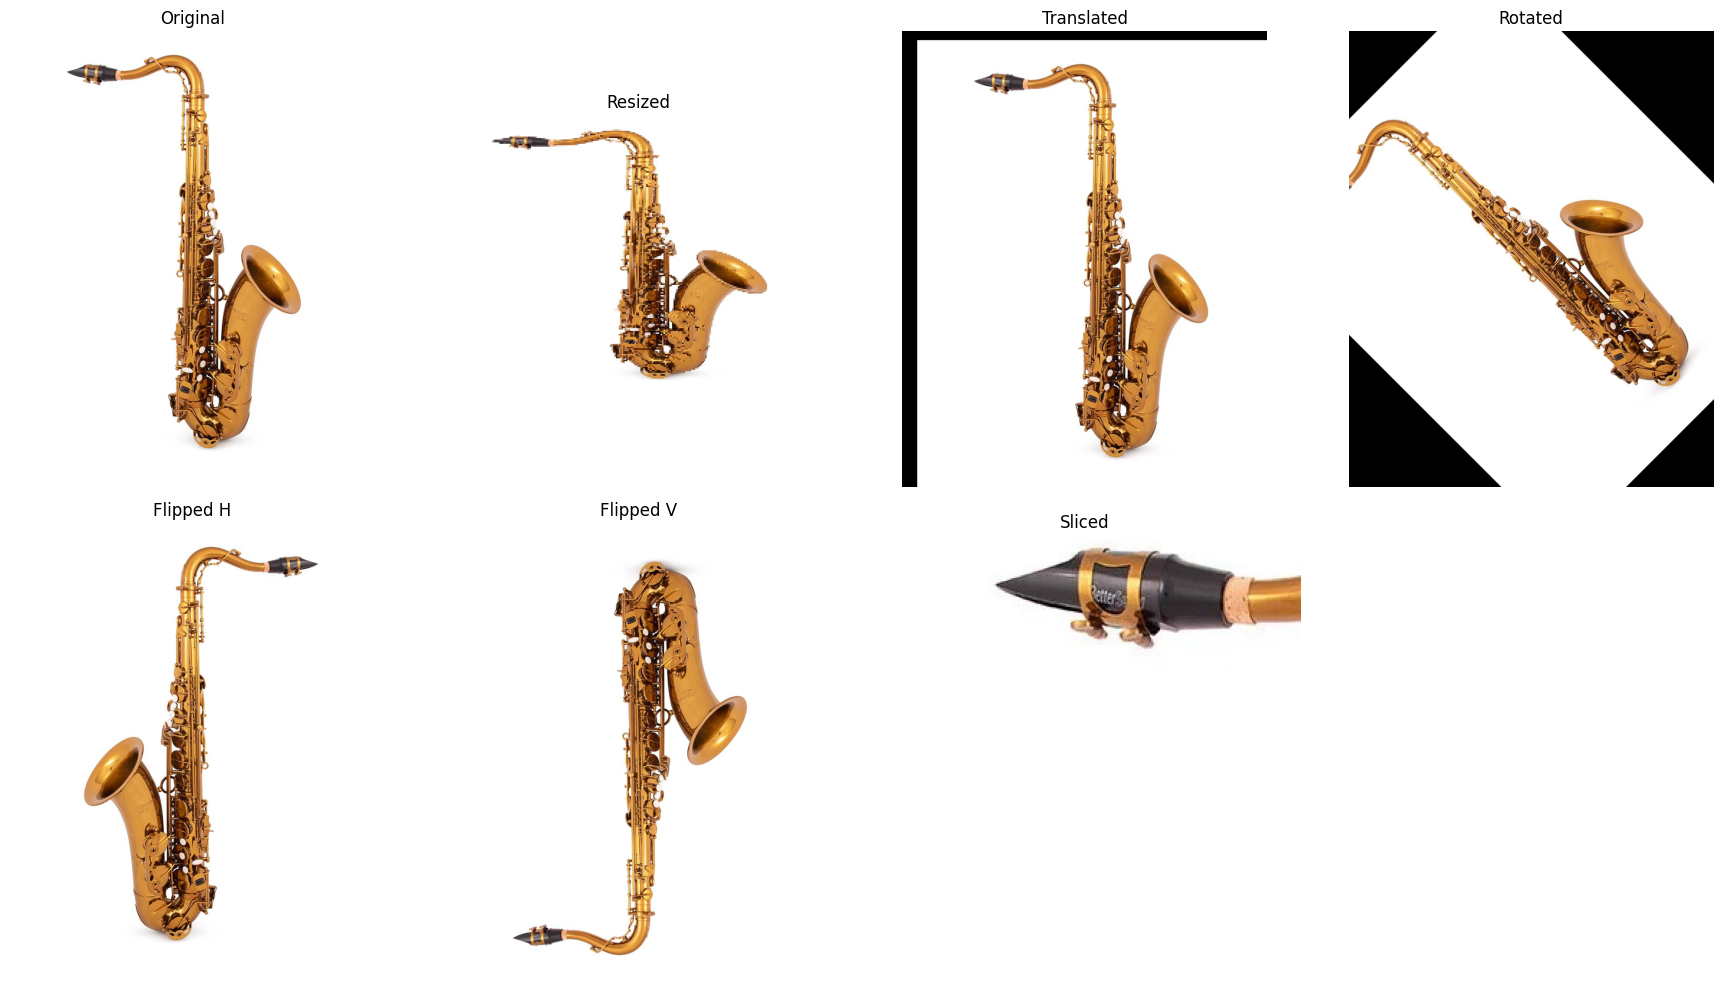

In [15]:
titles = ['Original', 'Resized', 'Translated', 'Rotated', 'Flipped H', 'Flipped V', 'Sliced']
images = [img_rgb, resized, translated, rotated, flip_h, flip_v, slice_img]

plt.figure(figsize=(18, 10))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()